# 신용카드 고객 이탈 예측 프로젝트
##  군집 모델링

데이터: `../data/processed/bankchurners_clean.csv`

목표: K-means를 사용해 고객을 이용 패턴이 비슷한 그룹으로 나누어 군집화에는 이탈 결과(Target)를 직접 사용하지 않고, 행동·이용 특성 변수만 사용.  
 이후 군집별 실제 이탈률을 비교해 어떤 유형의 고객군이 위험한지 확인

## 0. 라이브러리 & 데이터 로드

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/processed/bankchurners_clean.csv")
df.shape

(10127, 20)

## 1. 군집용 변수 선정

군집화에는 이탈 여부(Target)를 사용하지 않아, 지금까지 확인한 핵심 행동 변수 위주로 선정
- `Total_Trans_Ct`: 거래건수 (활동성)
- `Avg_Utilization_Ratio`: 한도소진율
- `Total_Revolving_Bal`: 리볼빙 잔액
- `Contacts_Count_12_mon`: 고객센터 문의 횟수
- `Total_Relationship_Count`: 보유 상품 개수

In [4]:
cluster_cols = [
    "Total_Trans_Ct", "Avg_Utilization_Ratio", "Total_Revolving_Bal",
    "Contacts_Count_12_mon", "Total_Relationship_Count",
]

X_cluster = df[cluster_cols].copy()
X_cluster.describe()

,Total_Trans_Ct,Avg_Utilization_Ratio,Total_Revolving_Bal,Contacts_Count_12_mon,Total_Relationship_Count
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,64.858695,0.274894,1162.814061,2.455317,3.812580
std,23.472570,0.275691,814.987335,1.106225,1.554408
min,10.000000,0.000000,0.000000,0.000000,1.000000
25%,45.000000,0.023000,359.000000,2.000000,3.000000
50%,67.000000,0.176000,1276.000000,2.000000,4.000000
75%,81.000000,0.503000,1784.000000,3.000000,5.000000
max,139.000000,0.999000,2517.000000,6.000000,6.000000


## 2. 스케일링

K-means는 거리(유클리드 거리) 기반 알고리즘이라 변수 간 스케일 차이에 민감하여 StandardScaler로 각 변수를 평균 0, 표준편차 1로 맞춘 뒤 군집화를 진행

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled[:5]

array([[-0.97389518, -0.77588223, -0.47342222,  0.49240377,  0.76394261],
       [-1.35734038, -0.61627565, -0.36666682, -0.41161598,  1.40730617],
       [-1.91120566, -0.99715499, -1.42685834, -2.21965548,  0.12057905],
       [-1.91120566,  1.75968594,  1.6616857 , -1.31563573, -0.52278451],
       [-1.57036549, -0.99715499, -1.42685834, -2.21965548,  0.76394261]])

## 3. 최적 군집 수 탐색 (Elbow Method + 실루엣 스코어)

군집 수(k)를 2~8까지 바꿔가며 inertia(군집 내 거리 제곱합)와 실루엣 스코어를 함께 확인  Elbow만으로는 적정 k가 애매하게 나오는 경우가 많아, 실루엣 스코어를 함께 비교해 최종 k를 결정

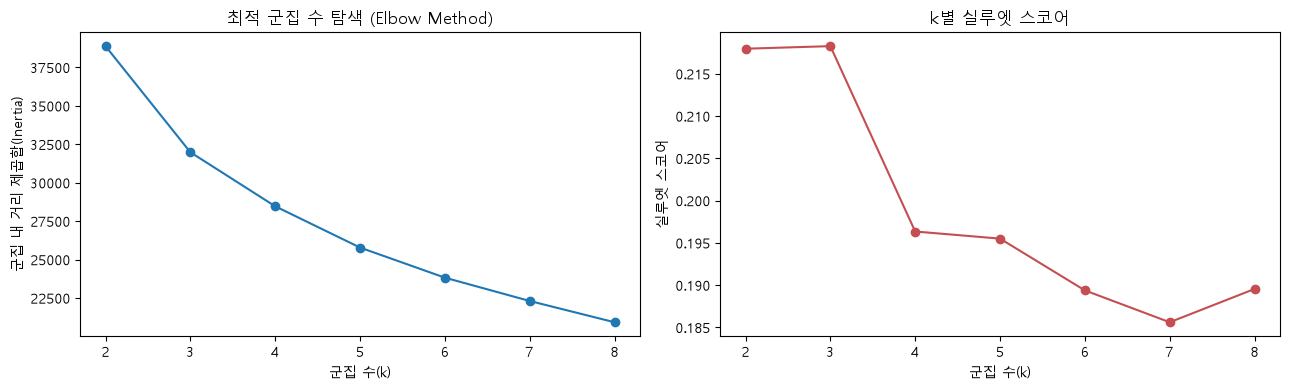

k=2: 실루엣 스코어 0.218
k=3: 실루엣 스코어 0.218
k=4: 실루엣 스코어 0.196
k=5: 실루엣 스코어 0.196
k=6: 실루엣 스코어 0.189
k=7: 실루엣 스코어 0.186
k=8: 실루엣 스코어 0.190


In [5]:
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
k_range = range(2, 9)

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_scaled), size=min(3000, len(X_scaled)), replace=False)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled[sample_idx], labels[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("군집 수(k)")
axes[0].set_ylabel("군집 내 거리 제곱합(Inertia)")
axes[0].set_title("최적 군집 수 탐색 (Elbow Method)")

axes[1].plot(list(k_range), sil_scores, marker="o", color="#C44E52")
axes[1].set_xlabel("군집 수(k)")
axes[1].set_ylabel("실루엣 스코어")
axes[1].set_title("k별 실루엣 스코어")

plt.tight_layout()
plt.show()

for k, s in zip(k_range, sil_scores):
    print(f"k={k}: 실루엣 스코어 {s:.3f}")

## 4. K-means 학습 (k=3)

k=2~7 비교 결과, k=3에서 실루엣 스코어가 가장 높게(0.218) 나왔고 k=2와도 동률이었으나, 3개 그룹으로 나눴을 때 군집별 성격(동면형/락인형/활성형)이 더 명확하게 해석되어 k=3으로 최종 확정

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df["Cluster"].value_counts().sort_index()

Cluster
0    3597
1    4139
2    2391
Name: count, dtype: int64

## 5. 군집별 특성 프로파일링

각 군집의 변수별 평균값을 확인하여 군집마다 어떤 성격을 갖는지 파악.

In [14]:
cluster_profile = df.groupby("Cluster")[cluster_cols].mean().round(2)
cluster_profile

,Total_Trans_Ct,Avg_Utilization_Ratio,Total_Revolving_Bal,Contacts_Count_12_mon,Total_Relationship_Count
Cluster,,,,,
0,56.79,0.04,342.52,2.71,4.02
1,57.35,0.49,1736.33,2.51,4.55
2,90.00,0.26,1404.06,1.98,2.22


## 6. 군집별 실제 이탈률 비교

군집화 자체에는 이탈 여부를 쓰지 않았지만, 결과 검증 차원에서 군집별 실제 이탈률(Target)을 확인  
특정 군집의 이탈률이 유독 높다면, 그 군집이 곧 위험군이라는 뜻

군집별 이탈률(%):
Cluster
0    31.8
1     9.6
2     3.5
Name: Target, dtype: float64


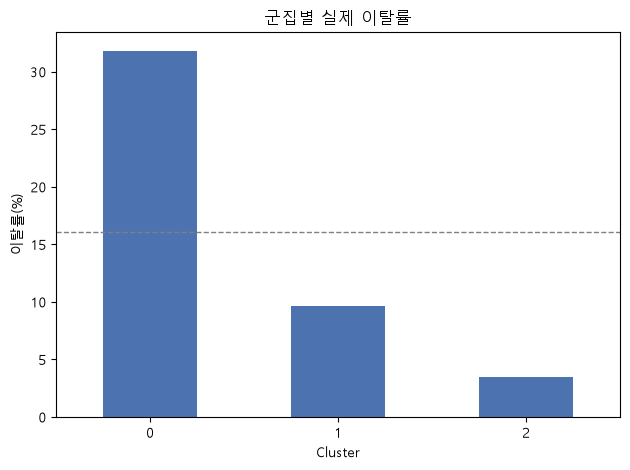

In [15]:
churn_rate_by_cluster = df.groupby("Cluster")["Target"].mean() * 100

print("군집별 이탈률(%):")
print(churn_rate_by_cluster.round(1))

churn_rate_by_cluster.plot(kind="bar", color="#4C72B0", rot=0)
plt.ylabel("이탈률(%)")
plt.title("군집별 실제 이탈률")
plt.axhline(df["Target"].mean() * 100, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

## 7. 군집 시각화 (거래건수 vs 한도소진율)

5차원 변수를 한 번에 시각화할 수는 없어 대표적인 두 변수(거래건수, 한도소진율)의 산점도.

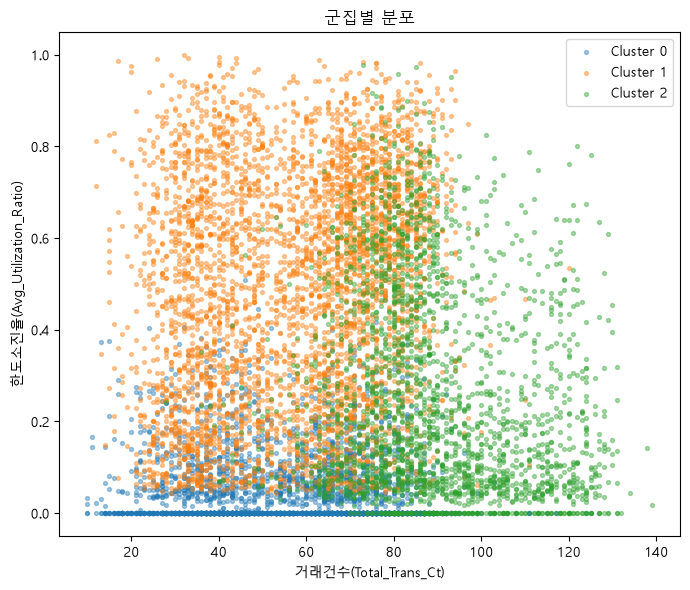

In [16]:
plt.figure(figsize=(7, 6))
for c in sorted(df["Cluster"].unique()):
    sub = df[df["Cluster"] == c]
    plt.scatter(sub["Total_Trans_Ct"], sub["Avg_Utilization_Ratio"],
                s=8, alpha=0.4, label=f"Cluster {c}")

plt.xlabel("거래건수(Total_Trans_Ct)")
plt.ylabel("한도소진율(Avg_Utilization_Ratio)")
plt.title("군집별 분포")
plt.legend()
plt.tight_layout()
plt.show()

## 8. 군집 분리도 정량 검증 — 실루엣 스코어

실루엣 스코어는 각 데이터가 자기 군집 안에서는 얼마나 가깝고,   
다른 군집과는 얼마나 멀리 떨어져 있는지를 -1~1 사이 숫자로 나타내,    
1에 가까울수록 군집이 잘 나뉜 것이고, 0에 가까우면 군집 경계가 애매하다는 뜻

In [17]:
from sklearn.metrics import silhouette_samples

sil_score = silhouette_score(X_scaled[sample_idx], df["Cluster"].values[sample_idx])
print(f"전체 평균 실루엣 스코어: {sil_score:.3f}")

sil_samples = silhouette_samples(X_scaled[sample_idx], df["Cluster"].values[sample_idx])
sil_df = pd.DataFrame({"Cluster": df["Cluster"].values[sample_idx], "silhouette": sil_samples})
sil_df.groupby("Cluster")["silhouette"].mean().round(3)

전체 평균 실루엣 스코어: 0.218


Cluster
0    0.254
1    0.184
2    0.227
Name: silhouette, dtype: float64

## 9. PCA로 5차원을 2차원으로 압축해 시각화

앞서 본 산점도는 5개 변수 중 2개만 뽑아서 본 것이라 실제 분리도를 과소평가했을 수 있어,  
PCA(주성분분석)로 5개 변수의 정보를 최대한 보존하면서 2차원으로 압축한 뒤 다시 시각화

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PC1, PC2가 설명하는 분산 비율: {pca.explained_variance_ratio_}")
print(f"두 성분의 누적 설명 비율: {pca.explained_variance_ratio_.sum():.1%}")

PC1, PC2가 설명하는 분산 비율: [0.3281121 0.2625814]
두 성분의 누적 설명 비율: 59.1%


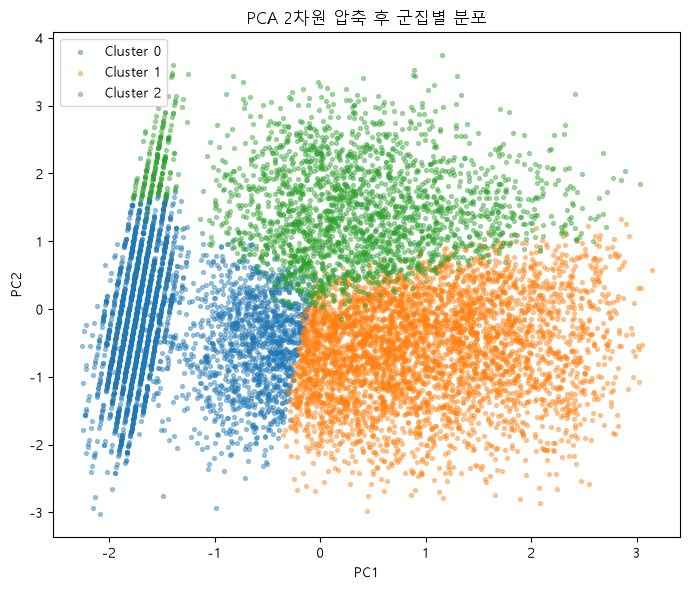

In [19]:
plt.figure(figsize=(7, 6))
for c in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == c
    plt.scatter(X_pca[mask.values, 0], X_pca[mask.values, 1],
                s=8, alpha=0.4, label=f"Cluster {c}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2차원 압축 후 군집별 분포")
plt.legend()
plt.tight_layout()
plt.show()

## 10. 군집 해석

프로파일링 및 이탈률 결과를 바탕으로 각 군집에 이름을 붙임.

- **군집 0 — "동면 위험 고객"**
  - 한도소진율이 사실상 0에 가깝고, 리볼빙잔액도 다른 군집 대비 압도적으로 낮음
  - 카드는 있지만 거의 안 쓰는 상태로 해석됨
  - 실제 이탈률이 세 군집 중 가장 높게 나타남

- **군집 1 — "한도 락인·다상품 보유형"**
  - 한도소진율과 리볼빙잔액이 세 군집 중 가장 높음
  - 보유 상품 개수도 가장 많아 관계가 깊은 고객군으로 해석됨
  - 실제 이탈률이 낮은 편으로, 카드 의존도가 높아 이탈이 어려운 락인 상태로 볼 수 있음

- **군집 2 — "우량 활성 고객"**
  - 거래건수가 세 군집 중 압도적으로 높음
  - 고객센터 문의 횟수는 가장 적어 불만 없이 카드를 꾸준히 쓰는 유형으로 해석됨
  - 실제 이탈률이 세 군집 중 가장 낮음


## 군집별 특성 및 전략 요약

| 군집 유형 | 특징 | 실제 이탈률 | 전략 |
|---|---|---|---|
| 우량 활성형 (군집 2) | 거래건수 압도적으로 높음, 문의횟수 가장 적음 | 매우 낮음 | VIP 등급 상향, 프리미엄 혜택 |
| 한도 락인·다상품형 (군집 1) | 한도소진율·리볼빙잔액·보유상품 수 가장 높음 | 낮음 | 한도 상향 제안, 크로스셀 강화 |
| **동면 위험형 (군집 0)** | 한도소진율·리볼빙잔액 거의 0 (방치 상태) | **가장 높음** | 재활성화 캠페인, 사용 유도 알림 |


## 정리

- 이탈 결과를 사용하지 않고 행동 변수만으로 군집화를 진행하여 k=2~7을 비교한 뒤 k=3으로 최종 확정
- 군집별 실제 이탈률을 비교한 결과, 한도소진율과 리볼빙잔액이 거의 0에 가까운 "동면 위험 고객" 군집의 이탈률이 나머지 군집보다 뚜렷하게 높게 나타남.
- 실루엣 스코어와 PCA 시각화를 통해, 완벽하게 깨끗한 분리는 아니지만 동면 위험군과 우량 활성군은 상대적으로 잘 구분되는 것을 확인-> 이는 고객 행동 데이터가 몇 개의 뚜렷한 타입보다는 연속적인 스펙트럼에 가깝다는 데이터 자체의 특성으로 해석됨.
- 분류(이탈확률)·회귀(활동성 갭)와 이 군집 결과를 결합하면, 고객군별로 차별화된 유지 전략을 세울 수 있음.

## 변화 패턴 기반 군집화
- 변화율 패턴이 비슷한 고객끼리 묶기

| | 현재 `05_clustering` | 변화 패턴 군집 |
|---|---|---|
| 질문 | 지금 얼마나 쓰는 고객인가? | 최근에 어떻게 바뀌었는가? |
| 핵심 변수 | 거래건수, 한도소진, 리볼빙 | 1분기 대비 4분기 거래건수 변화율, 거래금액 변화율, 비활성 |
| 기대 결과 | 동면 위험 / 우량 활성 | 급감형 / 완만감소형 / 안정형 |

## 사용한 모델

| 항목 | 내용 |
|---|---|
| 모델 | **K-means** (`sklearn.cluster.KMeans`) |
| 전처리 | **StandardScaler** (평균 0, 분산 1) |
| 평가 | **Inertia**(Elbow) + **Silhouette** |
| 입력 | 변화율 2개 + 비활성 + 거래건수 (4변수) |
| 최종 k | **3** (`BEST_K = 3`) |
| 설정 | `random_state=42`, `n_init=10` |

1분기 1~3월   연초 거래량과 연말 거래량 비교  
2분기 4~6월  
3분기 7~9월  
4분기 10~12월  

Ct_Pattern
완만감소    5837
급감      2808
안정      1061
증가       421
Name: count, dtype: int64
Ct_Pattern
급감      0.358262
완만감소    0.087888
안정      0.081056
증가      0.052257
Name: Target, dtype: float64


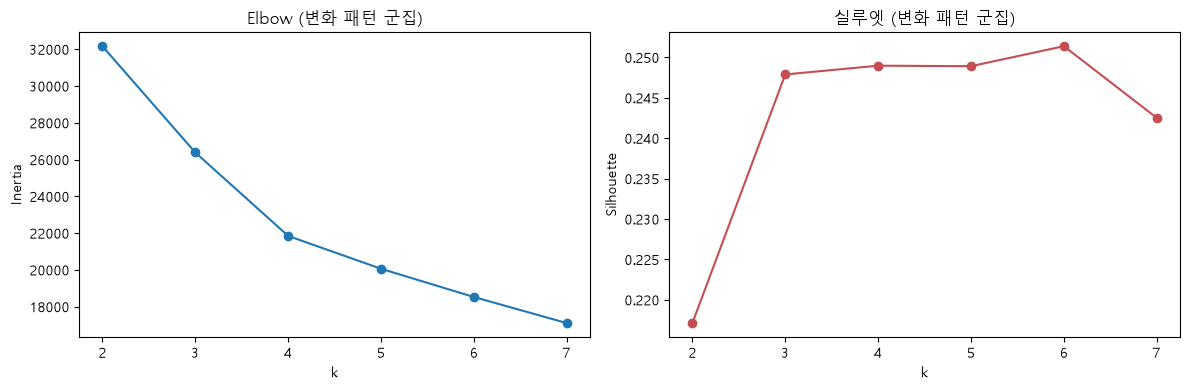

k=2: 실루엣 0.217
k=3: 실루엣 0.248
k=4: 실루엣 0.249
k=5: 실루엣 0.249
k=6: 실루엣 0.251
k=7: 실루엣 0.243
                 Total_Ct_Chng_Q4_Q1  Total_Amt_Chng_Q4_Q1  \
Pattern_Cluster                                              
0                              0.534                 0.642   
1                              0.738                 0.749   
2                              1.008                 1.069   

                 Months_Inactive_12_mon  Total_Trans_Ct     n  churn_rate  
Pattern_Cluster                                                            
0                                 2.589          42.870  3129      0.4097  
1                                 2.242          81.244  5601      0.0377  
2                                 2.183          48.415  1397      0.0959  
              count    mean
Pattern_Name               
급감형            3129  0.4097
안정·증가형         1397  0.0959
완만감소형          5601  0.0377


In [13]:
# ===== 1. 변화 패턴용 변수 =====
pattern_cols = [
    "Total_Ct_Chng_Q4_Q1",   # 1분기 대비 4분기 거래건수 변화율
    "Total_Amt_Chng_Q4_Q1",  # 1분기 대비 4분기 거래금액 변화율
    "Months_Inactive_12_mon", # 비활성 개월 (변화의 결과 신호)
    "Total_Trans_Ct",         # 절대 수준 (급감이어도 고이용/저이용 구분)
]

X_pat = df[pattern_cols].copy()

# ===== 2. 해석용 패턴 라벨 (규칙 기반, 참고용) =====
# 비율 < 1 = Q4가 Q1보다 감소, 1 = 동일, > 1 = 증가
def label_change(x):
    if x < 0.6:
        return "급감"
    elif x < 0.9:
        return "완만감소"
    elif x <= 1.1:
        return "안정"
    else:
        return "증가"

df["Ct_Pattern"] = df["Total_Ct_Chng_Q4_Q1"].map(label_change)
df["Amt_Pattern"] = df["Total_Amt_Chng_Q4_Q1"].map(label_change)

print(df["Ct_Pattern"].value_counts())
print(df.groupby("Ct_Pattern")["Target"].mean().sort_values(ascending=False))

# ===== 3. 스케일링 =====
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler_pat = StandardScaler()
X_pat_scaled = scaler_pat.fit_transform(X_pat)

# ===== 4. k=2~7 비교 =====
inertias, sils = [], []
k_range = range(2, 8)
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_pat_scaled), size=min(3000, len(X_pat_scaled)), replace=False)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pat_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pat_scaled[sample_idx], labels[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow (변화 패턴 군집)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), sils, marker="o", color="#C44E52")
axes[1].set_title("실루엣 (변화 패턴 군집)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

for k, s in zip(k_range, sils):
    print(f"k={k}: 실루엣 {s:.3f}")

# ===== 5. 최종 군집 (예: k=3 → 급감/완만/안정·증가에 대응하기 좋음) =====
BEST_K = 3  # 위 그래프 보고 조정
km_pat = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df["Pattern_Cluster"] = km_pat.fit_predict(X_pat_scaled)

# ===== 6. 프로파일링 + 이탈률 =====
profile = (
    df.groupby("Pattern_Cluster")[pattern_cols]
    .mean()
    .round(3)
)
profile["n"] = df.groupby("Pattern_Cluster").size()
profile["churn_rate"] = df.groupby("Pattern_Cluster")["Target"].mean().round(4)
profile = profile.sort_values("Total_Ct_Chng_Q4_Q1")  # 변화율 낮은 순 = 급감쪽
print(profile)

# 군집 평균으로 이름 붙이기
name_map = {}
for c, row in profile.iterrows():
    ct = row["Total_Ct_Chng_Q4_Q1"]
    if ct < 0.65:
        name_map[c] = "급감형"
    elif ct < 0.85:
        name_map[c] = "완만감소형"
    else:
        name_map[c] = "안정·증가형"

df["Pattern_Name"] = df["Pattern_Cluster"].map(name_map)
print(df.groupby("Pattern_Name")["Target"].agg(["count", "mean"]).round(4))

k=2: 실루엣 0.217   
k=3: 실루엣 0.248  
k=4: 실루엣 0.249  
k=5: 실루엣 0.249  
k=6: 실루엣 0.251  
k=7: 실루엣 0.243 1에 가까울수록 군집화가 잘됨

## 변화 패턴 군집 — 최적 k 탐색 (Elbow + 실루엣)

### Elbow Method
| k | Inertia (대략) | 해석 |
|---|---|---|
| 2 | 32,000 | 기준점 |
| 3 | 26,400 | 급격히 감소 |
| 4 | 21,800 | **Elbow 후보** (이후 감소폭 완만) |
| 5 | 20,100 | 감소 완만 |
| 6 | 18,500 | 감소 완만 |
| 7 | 17,100 | 감소 완만 |

- 의미: 군집 내 거리 제곱합. 낮을수록 군집이 촘촘함
- 판단: **k=4**에서 꺾임이 가장 뚜렷함

### 실루엣 스코어
| k | Silhouette | 해석 |
|---|---|---|
| 2 | 0.217 | 가장 낮음 |
| 3 | 0.248 | 큰 폭 상승 |
| 4 | 0.249 | 3과 거의 동일 |
| 5 | 0.249 | 평탄 |
| 6 | 0.251 | **최고점** (차이는 미미) |
| 7 | 0.243 | 하락 (과분할 징후) |

- 의미: 군집 분리 품질. 높을수록 좋음
- 판단: **k=3~6이 사실상 동등**, 최고는 k=6

### 종합
| 기준 | 추천 k |
|---|---|
| Elbow | 4 |
| 실루엣 | 6 (미세 우위) |
| 해석·전략 편의 | 3 |

→ 실무적으로는 **k=3 또는 k=4** 권장

## 고급화는 언제 하나?

| 상황 | 왜 고급화가 필요한가 |
|---|---|
| 군집 해석이 애매할 때 | k=3인데 군집 특성이 겹쳐 “급감/완만/안정”이 안 나뉨 |
| 실루엣이 계속 낮을 때 | 0.25 전후라 경계가 흐림 → GMM·이상치 처리로 품질 개선 |
| 전략/대시보드에 넣을 때 | “이 고객이 급감형일 확률 80%”처럼 확률·안정성이 필요 |
| 발표·보고서에서 한 단계 더 보여줄 때 | 단순 K-means 대비 비교·교차분석으로 설득력 보강 |
| 이탈 예측과 결합할 때 | 군집 × 이탈확률로 우선순위 고객을 더 정확히 뽑을 때 |

→ 지금은 K-means + Elbow/실루엣 + 프로파일링이면 충분.  
→ 고급화는 “결과가 약하다” 또는 “운영에 써야 한다”고 느껴질 때 진행.

실루엣 0.25대, elbow도 명확한 편이고, 급감/완만/안정으로 이름 붙여 이탈률까지 보면 프로젝트 목적에는 충분합니다.  
이 데이터 자체가 경계가 흐린 편이라 고급화해도 점수가 크게 오르기 어렵습니다.  
고급화는 나중에 군집이 안 갈리거나, 대시보드/운영에 확률 안정성이 필요할 때만 하면 됩니다.



ai한테 물어보니 현상태로는 수치가 명확해서 고급화 할 필요 없다고 해서 안했고, 코드는 한눈에 보게 할려고 합쳐서 문단만 나눴습니다. 추 후에 수정과 다음 작업시에는 나눠서 해볼까 합니다.

패턴 군집별 이탈률(%):
Pattern_Name
급감형       41.0
완만감소형      3.8
안정·증가형     9.6
Name: Target, dtype: float64


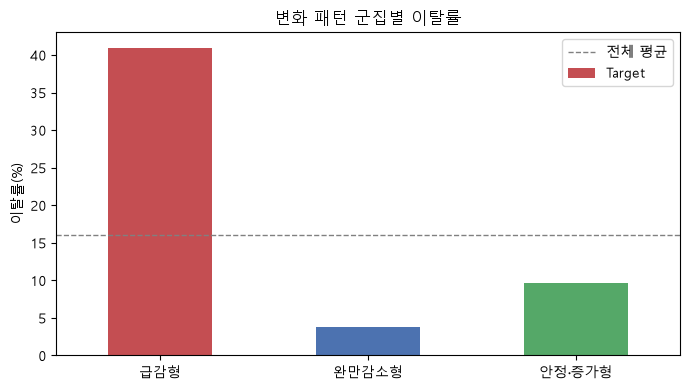

In [7]:
# ===== 변화 패턴 군집별 이탈률 시각화 =====
# 전체 평균(약 16.1%)과 비교해서 급감형 위험을 한눈에 확인

pat_churn = (
    df.groupby("Pattern_Name")["Target"]
    .mean()
    .mul(100)
    .reindex(["급감형", "완만감소형", "안정·증가형"])  # 해석 순서 고정
)

print("패턴 군집별 이탈률(%):")
print(pat_churn.round(1))

colors = {"급감형": "#C44E52", "완만감소형": "#4C72B0", "안정·증가형": "#55A868"}
ax = pat_churn.plot(kind="bar", color=[colors[n] for n in pat_churn.index], rot=0, figsize=(7, 4))
ax.set_ylabel("이탈률(%)")
ax.set_xlabel("")
ax.set_title("변화 패턴 군집별 이탈률")
ax.axhline(df["Target"].mean() * 100, color="gray", linestyle="--", linewidth=1, label="전체 평균")
ax.legend()
plt.tight_layout()
plt.show()


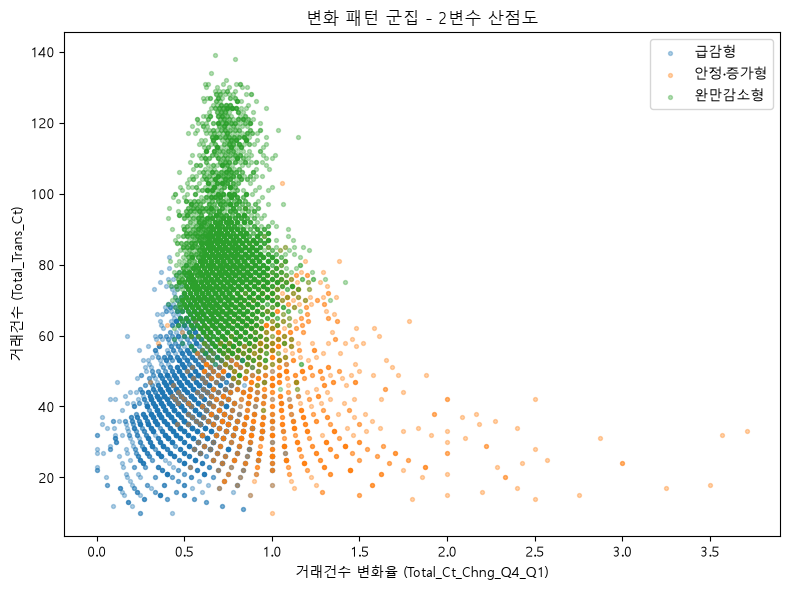

In [8]:
# ===== 7. 산점도 (해석용 2변수) =====
# x: 거래건수 변화율 / y: 절대 거래건수
# Pattern_Name으로 색을 칠해 군집이 얼마나 갈리는지 확인
# 급감 vs 고이용/저이용
fig, ax = plt.subplots(figsize=(8, 6))

for name, sub in df.groupby('Pattern_Name'):
    ax.scatter(
        sub["Total_Ct_Chng_Q4_Q1"],
        sub["Total_Trans_Ct"],
        s=8, alpha=0.35, label=name
    )

ax.set_xlabel('거래건수 변화율 (Total_Ct_Chng_Q4_Q1)')
ax.set_ylabel("거래건수 (Total_Trans_Ct)")
ax.set_title('변화 패턴 군집 - 2변수 산점도')
ax.legend()
plt.tight_layout()
plt.show()

보는 법: 색이 겹치면 경계가 흐린 것. 왼쪽(변화율↓)=급감형, 오른쪽=안정·증가형으로 갈리면 해석이 잘 된 것.

pca(주성분분석) : 변수가 많을 때, 정보를 최대한 유지하면서 차원을 줄이는 방법
- pc1 : 분산(차이)를 가장 많이 설명하는 축
- pc2 : 그 다음으로 많이 설명하는 축  
여러 변수 를 요약된 2축 으로 바꿔서 군집이 얼마나 갈리는지 눈으로 보게 해주는 도구 

PC1, PC2 설명 분산 비율: [0.353 0.256]
누적 설명력: 0.609


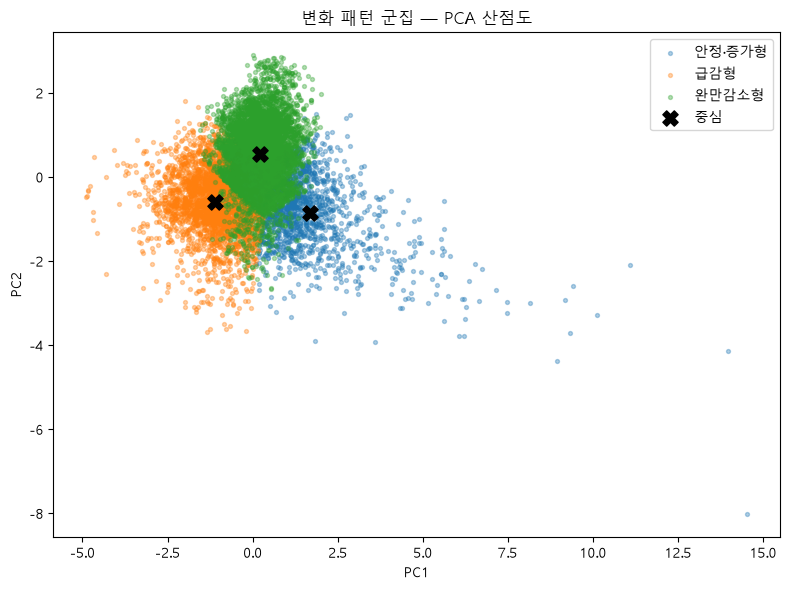

In [9]:
# pca 산점도 (추천, 분리도 확인용)
from sklearn.decomposition import PCA

pca_pat = PCA(n_components=2, random_state=42)
X_pat_pca = pca_pat.fit_transform(X_pat_scaled)

print("PC1, PC2 설명 분산 비율:", pca_pat.explained_variance_ratio_.round(3))
print("누적 설명력:", pca_pat.explained_variance_ratio_.sum().round(3))
fig, ax = plt.subplots(figsize=(8, 6))
for name in df["Pattern_Name"].unique():
    mask = df["Pattern_Name"] == name
    ax.scatter(
        X_pat_pca[mask, 0],
        X_pat_pca[mask, 1],
        s=8, alpha=0.35, label=name
    )
# 군집 중심 (스케일된 공간 → PCA 좌표)
centers_pca = pca_pat.transform(km_pat.cluster_centers_)
ax.scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    c="black", s=120, marker="X", label="중심"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("변화 패턴 군집 — PCA 산점도")
ax.legend()
plt.tight_layout()
plt.show()

보는법
- 색 덩어리가 떨어져 있으면 - 군집화가 잘된편
- 많이 섞이면 → 실루엣 ~0.25처럼 경계가 애매한 상태 (데이터 특성상 흔함)
- 검은 X = 각 군집의 중심

1. 비즈니스 해석(급감형인지) 
2. 수학적 분리도(실제로 갈렸는지)

- 현재 분리가 약한편,중심위치가 다른다 3유형이 구분이 됨.
- 파랑(급감형)오른쪽으로 길게 뻗은 건 안정,증가형 안에 극단값이 있다.

프로젝트 관점:
“완벽한 분리”보다는 급감형 이탈률이 높은지 같은 해석이 되면 실용적으로는 쓸 만해. 군집 “품질 점수”만 보면 약한 편이고, 세그먼트 해석용으로는 괜찮은 수준이야.

고객을 비슷한 그룹(세그먼트)설명하는 목적 거래변화패턴(1분기 대비 4분기 건수,금액 변화 + 비활성 절대 거래량)  

성격
- 급감형 - 거래가 확 줄고 이탈율 41% -> 우선 케어 대상
- 완만감소형 -> 대체로 안정, 이탈 낮음 이탈율-9.6% 
- 안정/증가형 -> 상대적으로 양호 이탈율-3.8%
그룹별 성격,이탈 위험도를 해석하는 군집도 입니다.

둘다 평균 이탈율수치 